In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
OUTPUT_DIR = Path("../reports")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("07 — LEAKAGE ANALYSIS: Address / IP / Port Feature Removal")
print("=" * 60)

07 — LEAKAGE ANALİZİ: Address / IP / Port Feature Removal


In [ ]:
FEATURED_PATH  = "../data/csv/featured_dataset.csv"
FEATURES_TXT   = "../data/csv/selected_features.txt"
LABEL_MAP_PATH = "../data/csv/label_mapping.csv"

# Read feature list (same method as 04_modeling)
with open(FEATURES_TXT) as f:
    FEATURE_COLS = [line.strip() for line in f if line.strip()]

label_mapping = pd.read_csv(LABEL_MAP_PATH)
INT_TO_LABEL  = dict(zip(label_mapping["label_int"], label_mapping["label_string"]))

df = pd.read_csv(FEATURED_PATH, low_memory=False)

print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Selected features: {len(FEATURE_COLS)} items")
print(f"Number of classes: {df['label_multiclass'].nunique()}")

Dataset: 495,855 satır, 51 sütun
Selected features: 47 adet
Sınıf sayısı: 12


In [ ]:
# Leakage patterns — CIC-IDS2017 specific
LEAKAGE_PATTERNS = [
    r"source.?address", r"destination.?address",
    r"src.?ip", r"dst.?ip",
    r"source.?ip", r"destination.?ip",
    r"flow.?id",
    r"timestamp",
]

# Destination Port — special case (important for the model but has leakage risk)
PORT_PATTERNS = [
    r"^destination.?port$",
]

def find_matching_columns(columns, patterns):
    """Find column names that match the given patterns."""
    found = []
    for col in columns:
        col_norm = col.lower().strip().replace(" ", "_")
        for pat in patterns:
            if re.search(pat, col_norm):
                found.append(col)
                break
    return sorted(set(found))

# Detection
leakage_cols = find_matching_columns(FEATURE_COLS, LEAKAGE_PATTERNS)
port_cols    = find_matching_columns(FEATURE_COLS, PORT_PATTERNS)
all_remove   = sorted(set(leakage_cols + port_cols))

print("=" * 60)
print("LEAKAGE RISK DETECTION")
print("=" * 60)
print(f"\nAddress/IP based leakage columns: {leakage_cols if leakage_cols else 'NONE'}")
print(f"Port based leakage columns:       {port_cols if port_cols else 'NONE'}")
print(f"\nTotal to remove: {len(all_remove)} features")
for col in all_remove:
    print(f"  - {col}")

if not port_cols:
    print("\n[INFO] 'Destination Port' is in selected_features.txt")
    # Direct check
    dp_check = [c for c in FEATURE_COLS if "destination" in c.lower() and "port" in c.lower()]
    if dp_check:
        print(f"  Found: {dp_check} — adding to removal list.")
        all_remove = sorted(set(all_remove + dp_check))
    else:
        print("  Destination Port feature not found in the feature list.")
        print("  It may have been removed in 03_feature_engineering by correlation/MI filtering.")

LEAKAGE RİSKİ TESPİTİ

Address/IP tabanlı leakage kolonları: YOK
Port tabanlı leakage kolonları:       ['Destination Port']

Toplam kaldırılacak: 1 feature
  - Destination Port


In [ ]:
def train_evaluate_rf(X, y, experiment_name, int_to_label=None):
    """
    Train RF, evaluate, and return metrics.
    Uses the same parameters as 04_modeling.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=2  # consistent with 04_modeling
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        "experiment":   experiment_name,
        "n_features":   X.shape[1],
        "accuracy":     accuracy_score(y_test, y_pred),
        "precision_w":  precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_w":     recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_weighted":  f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_macro":     f1_score(y_test, y_pred, average="macro", zero_division=0),
    }
    return model, metrics, y_test, y_pred


def plot_confusion_matrix(y_true, y_pred, title, save_path, int_to_label=None):
    """Plot and save confusion matrix."""
    labels = sorted(set(y_true) | set(y_pred))
    if int_to_label:
        display_labels = [int_to_label.get(l, str(l)) for l in labels]
    else:
        display_labels = [str(l) for l in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for ax, data, fmt, subtitle in [
        (axes[0], cm,      ",d",  "Raw Counts"),
        (axes[1], cm_norm, ".2f", "Normalized (Recall-based)")
    ]:
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=display_labels, yticklabels=display_labels,
                    ax=ax, annot_kws={"size": 7})
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(subtitle)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', rotation=0,  labelsize=7)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved: {save_path}")

DENEY 1: Tüm feature'lar dahil (BEFORE leakage removal)

  Feature sayısı : 47
  Accuracy       : 0.9964
  Precision (w)  : 0.9963
  Recall (w)     : 0.9964
  F1 Weighted    : 0.9963
  F1 Macro       : 0.9128


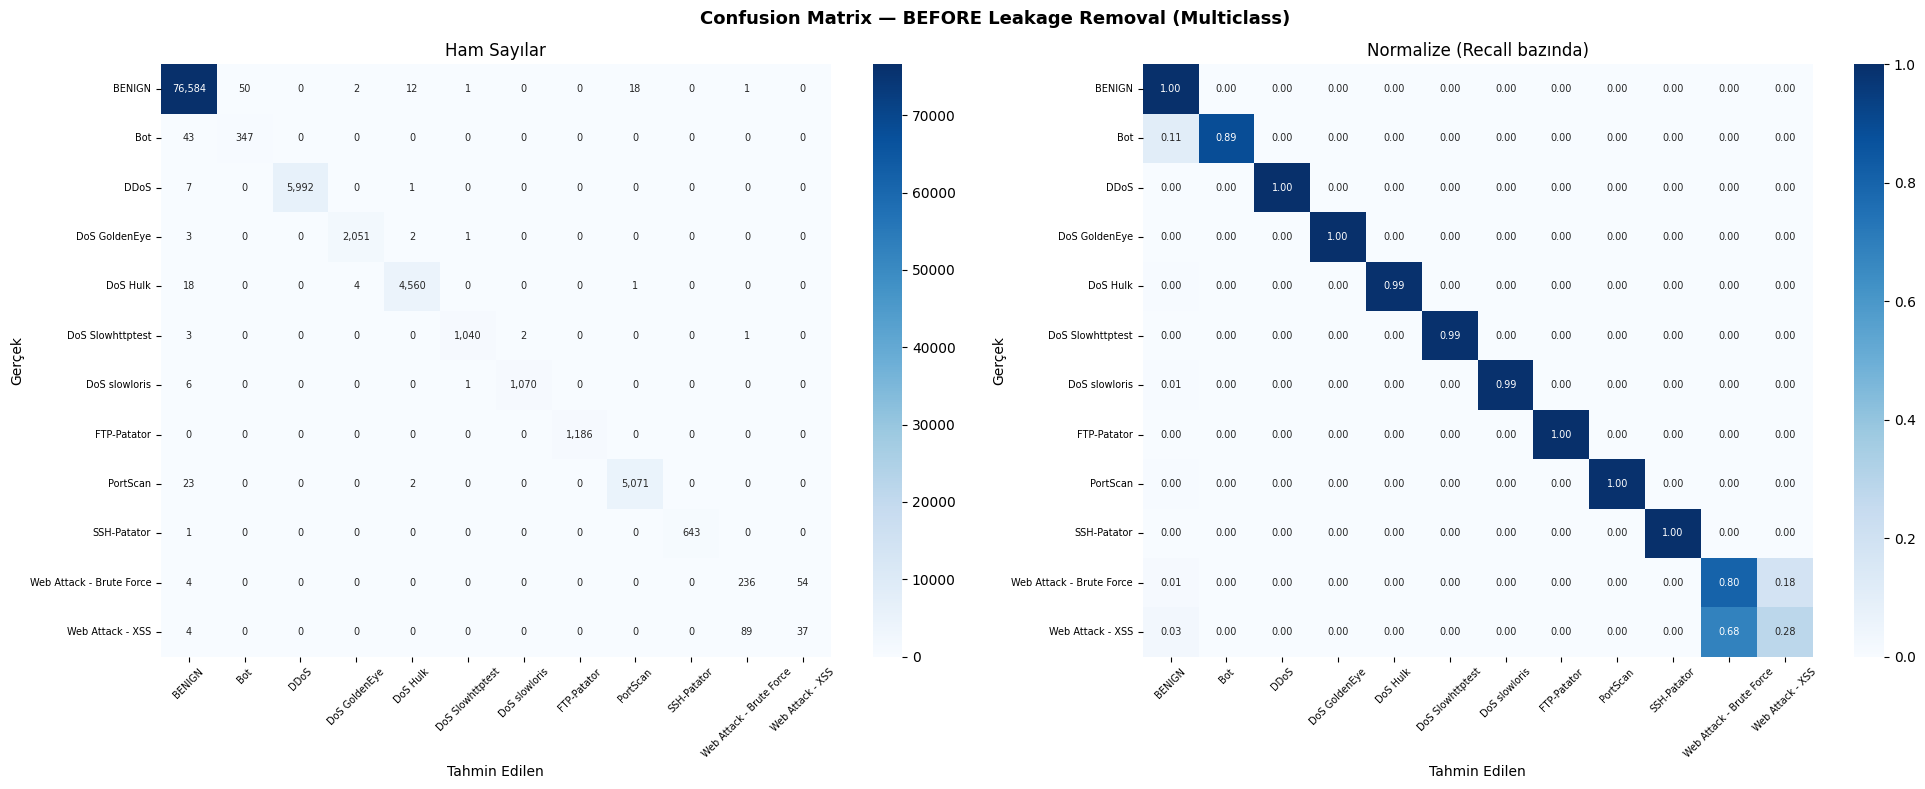

✓ Kaydedildi: ../reports/confusion_leakage_before.png


In [ ]:
print("=" * 60)
print("EXPERIMENT 1: All features included (BEFORE leakage removal)")
print("=" * 60)

X_before = df[FEATURE_COLS].values
y_mc     = df["label_multiclass"].values

_, metrics_before, yt_b, yp_b = train_evaluate_rf(
    X_before, y_mc, "BEFORE_leakage_removal", INT_TO_LABEL
)

print(f"\n  Number of features : {metrics_before['n_features']}")
print(f"  Accuracy           : {metrics_before['accuracy']:.4f}")
print(f"  Precision (w)      : {metrics_before['precision_w']:.4f}")
print(f"  Recall (w)         : {metrics_before['recall_w']:.4f}")
print(f"  F1 Weighted        : {metrics_before['f1_weighted']:.4f}")
print(f"  F1 Macro           : {metrics_before['f1_macro']:.4f}")

plot_confusion_matrix(
    yt_b, yp_b,
    "Confusion Matrix — BEFORE Leakage Removal (Multiclass)",
    OUTPUT_DIR / "confusion_leakage_before.png",
    INT_TO_LABEL
)

DENEY 2: Address/IP/Port feature'lar çıkarıldı (AFTER)
  Çıkarılan feature'lar (1):
    - Destination Port

  Kalan feature sayısı: 46

  Accuracy       : 0.9962
  Precision (w)  : 0.9961
  Recall (w)     : 0.9962
  F1 Weighted    : 0.9961
  F1 Macro       : 0.9108


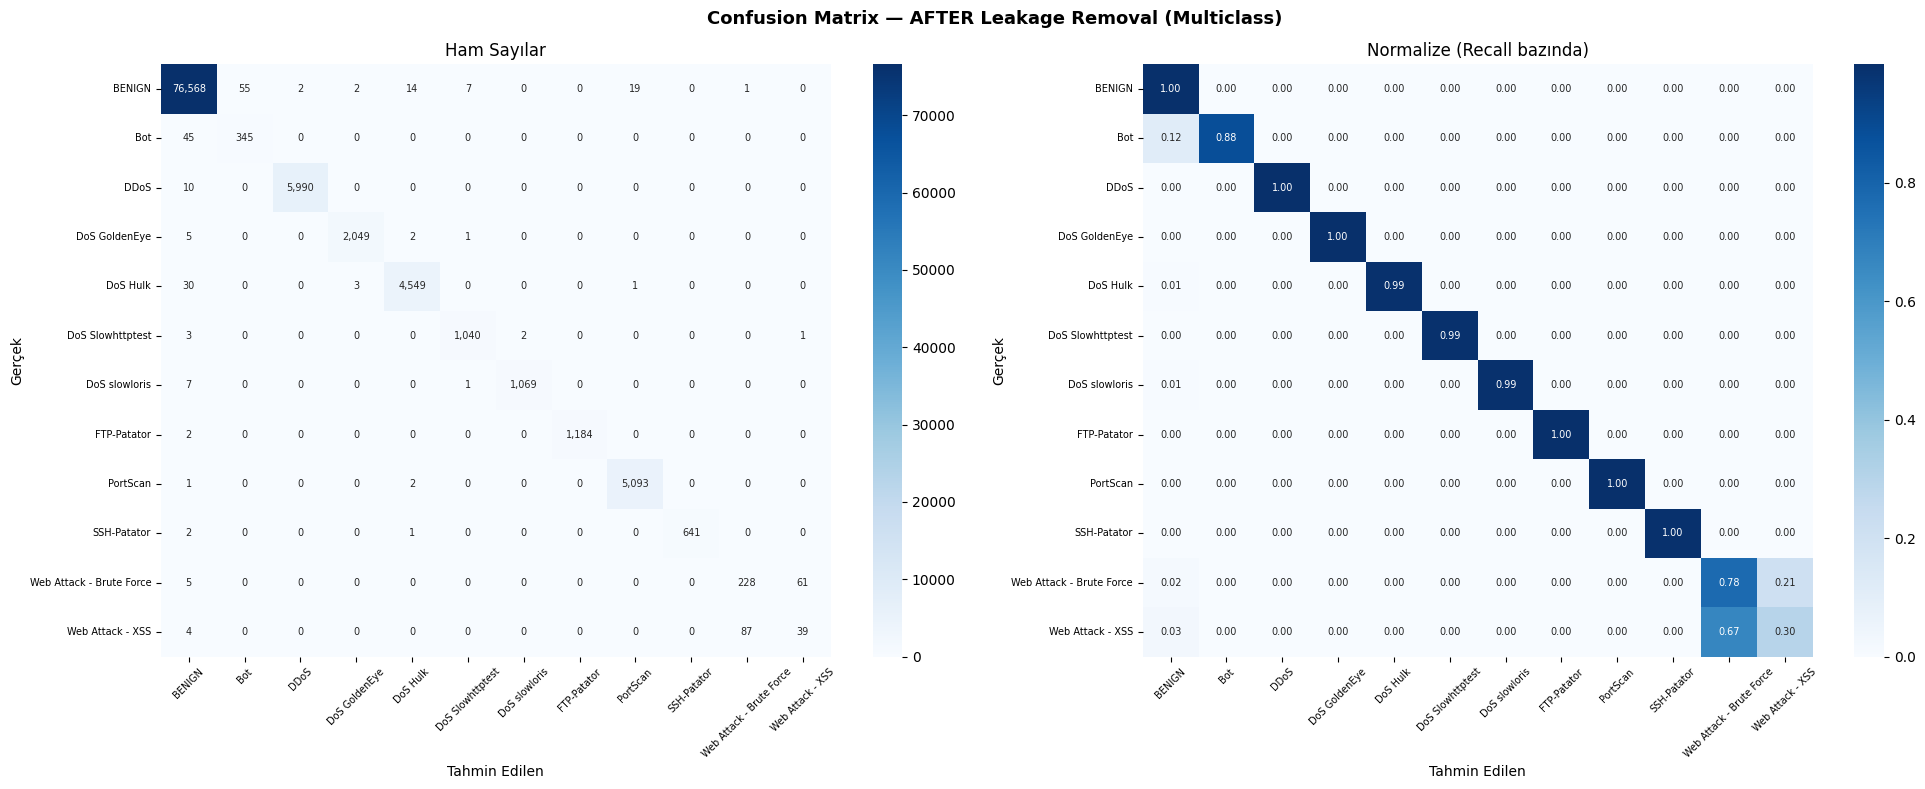

✓ Kaydedildi: ../reports/confusion_leakage_after.png


In [ ]:
print("=" * 60)
print("EXPERIMENT 2: Address/IP/Port features removed (AFTER)")
print("=" * 60)

# Remove only existing columns
features_after = [f for f in FEATURE_COLS if f not in all_remove]
actually_removed = [f for f in all_remove if f in FEATURE_COLS]
not_found        = [f for f in all_remove if f not in FEATURE_COLS]

print(f"  Removed features ({len(actually_removed)}):")
for f in actually_removed:
    print(f"    - {f}")
if not_found:
    print(f"  Not in the list already ({len(not_found)}):")
    for f in not_found:
        print(f"    - {f}")

print(f"\n  Remaining feature count: {len(features_after)}")

X_after = df[features_after].values

_, metrics_after, yt_a, yp_a = train_evaluate_rf(
    X_after, y_mc, "AFTER_leakage_removal", INT_TO_LABEL
)

print(f"\n  Accuracy       : {metrics_after['accuracy']:.4f}")
print(f"  Precision (w)  : {metrics_after['precision_w']:.4f}")
print(f"  Recall (w)     : {metrics_after['recall_w']:.4f}")
print(f"  F1 Weighted    : {metrics_after['f1_weighted']:.4f}")
print(f"  F1 Macro       : {metrics_after['f1_macro']:.4f}")

plot_confusion_matrix(
    yt_a, yp_a,
    "Confusion Matrix — AFTER Leakage Removal (Multiclass)",
    OUTPUT_DIR / "confusion_leakage_after.png",
    INT_TO_LABEL
)

In [ ]:
print("=" * 60)
print("LEAKAGE COMPARISON TABLE")
print("=" * 60)

comp_leakage = pd.DataFrame([metrics_before, metrics_after])
comp_leakage["delta_accuracy"]    = comp_leakage["accuracy"]    - metrics_before["accuracy"]
comp_leakage["delta_f1_weighted"] = comp_leakage["f1_weighted"] - metrics_before["f1_weighted"]
comp_leakage["delta_f1_macro"]    = comp_leakage["f1_macro"]    - metrics_before["f1_macro"]

display_cols = ["experiment", "n_features", "accuracy", "precision_w", "recall_w",
                "f1_weighted", "f1_macro", "delta_accuracy", "delta_f1_weighted", "delta_f1_macro"]

print(comp_leakage[display_cols].round(4).to_string(index=False))

# Save as CSV
comp_leakage.to_csv(OUTPUT_DIR / "leakage_comparison.csv", index=False)
print(f"\n✓ Saved: {OUTPUT_DIR / 'leakage_comparison.csv'}")

LEAKAGE KARŞILAŞTIRMA TABLOSU
            experiment  n_features  accuracy  precision_w  recall_w  f1_weighted  f1_macro  delta_accuracy  delta_f1_weighted  delta_f1_macro
BEFORE_leakage_removal          47    0.9964       0.9963    0.9964       0.9963    0.9128          0.0000             0.0000           0.000
 AFTER_leakage_removal          46    0.9962       0.9961    0.9962       0.9961    0.9108         -0.0002            -0.0002          -0.002

✓ Kaydedildi: ../reports/leakage_comparison.csv
